<a href="https://colab.research.google.com/github/mandaw34/Machine-Learning/blob/main/Praktikum4/Latihan_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Percobaan**

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATA_PATH = "/content/drive/MyDrive/dataset/advertising.csv"
df = pd.read_csv(DATA_PATH)

X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

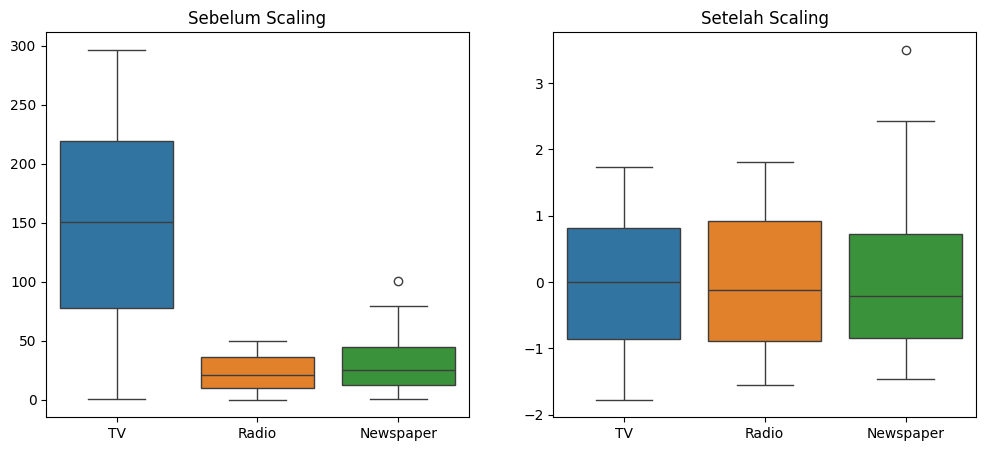

In [9]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(data=X_train[['TV','Radio','Newspaper']], ax=ax[0])
ax[0].set_title("Sebelum Scaling")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
sns.boxplot(data=X_train_scaled_df[['TV','Radio','Newspaper']], ax=ax[1])
ax[1].set_title("Setelah Scaling")
plt.show()

In [10]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

print("Linear Regression")
print("RMSE Train:", rmse_train_lr)
print("RMSE Test :", rmse_test_lr)
print("Coefficients:", lr.coef_)

Linear Regression
RMSE Train: 1.6358920055378559
RMSE Test : 1.7052146229349234
Coefficients: [4.58720774 1.48984025 0.08791597]


In [22]:
lambdas = [0.001, 0.05, 0.5, 5, 50]
from sklearn.metrics import mean_squared_error
import numpy as np

print("=== RIDGE ===")

for l in lambdas:
    ridge = Ridge(alpha=l)
    ridge.fit(X_train_scaled, y_train)

    y_train_pred = ridge.predict(X_train_scaled)
    y_test_pred = ridge.predict(X_test_scaled)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    print(f"Lambda: {l}")
    print(f"RMSE Train: {rmse_train:.4f}")
    print(f"RMSE Test : {rmse_test:.4f}")
    print("Koefisien :", ridge.coef_)
    print("----------------------")

=== RIDGE ===
Lambda: 0.001
RMSE Train: 1.6359
RMSE Test : 1.7052
Koefisien : [4.5871795  1.48983108 0.08791951]
----------------------
Lambda: 0.05
RMSE Train: 1.6359
RMSE Test : 1.7053
Koefisien : [4.58579598 1.4893821  0.08809318]
----------------------
Lambda: 0.5
RMSE Train: 1.6360
RMSE Test : 1.7063
Koefisien : [4.57312911 1.48527402 0.08967645]
----------------------
Lambda: 5
RMSE Train: 1.6423
RMSE Test : 1.7214
Koefisien : [4.45020505 1.44563967 0.10442055]
----------------------
Lambda: 50
RMSE Train: 1.9940
RMSE Test : 2.1490
Koefisien : [3.50752829 1.15139128 0.1827538 ]
----------------------


In [13]:
print("=== LASSO ===")

for l in lambdas:
    lasso = Lasso(alpha=l)
    lasso.fit(X_train_scaled, y_train)

    y_train_pred = lasso.predict(X_train_scaled)
    y_test_pred = lasso.predict(X_test_scaled)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    print(f"Lambda: {l}")
    print(f"RMSE Train: {rmse_train:.4f}")
    print(f"RMSE Test : {rmse_test:.4f}")
    print("Koefisien :", lasso.coef_)
    print("----------------------")

=== LASSO ===
Lambda: 0.001
RMSE Train: 1.6359
RMSE Test : 1.7052
Koefisien : [4.58625211 1.48918938 0.08718679]
----------------------
Lambda: 0.05
RMSE Train: 1.6377
RMSE Test : 1.7062
Koefisien : [4.53967644 1.45648686 0.05176667]
----------------------
Lambda: 0.5
RMSE Train: 1.7768
RMSE Test : 1.9087
Koefisien : [4.11260682 1.04952607 0.        ]
----------------------
Lambda: 5
RMSE Train: 5.1768
RMSE Test : 5.6482
Koefisien : [0. 0. 0.]
----------------------
Lambda: 50
RMSE Train: 5.1768
RMSE Test : 5.6482
Koefisien : [0. 0. 0.]
----------------------


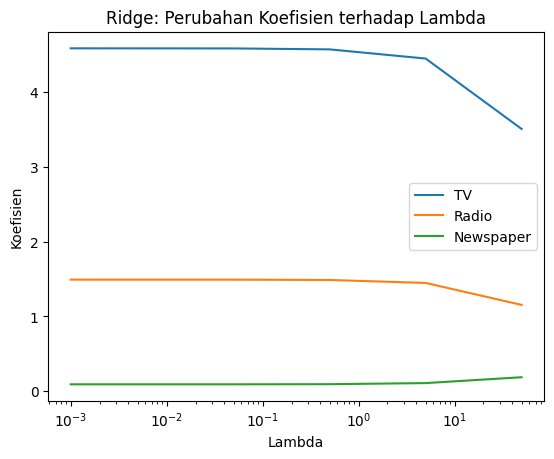

In [15]:
ridge_coefs = []

for l in lambdas:
    ridge = Ridge(alpha=l)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

ridge_coefs = np.array(ridge_coefs)

plt.figure()

for i in range(ridge_coefs.shape[1]):
    plt.plot(lambdas, ridge_coefs[:, i], label=X.columns[i])

plt.xscale('log')
plt.xlabel("Lambda")
plt.ylabel("Koefisien")
plt.title("Ridge: Perubahan Koefisien terhadap Lambda")
plt.legend()
plt.show()

# Evaluasi dan analisis terhadap kinerja model tanpa **Regularization**

Apakah Ridge menurunkan gap RMSE antara train dan test?

In [16]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

# Linear Regression (tanpa regularization)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_train_pred_lr = lr.predict(X_train_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

# Ridge
ridge = Ridge(alpha=1)
ridge.fit(X_train_scaled, y_train)

y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge = ridge.predict(X_test_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))

print("Linear Regression")
print("RMSE Train:", rmse_train_lr)
print("RMSE Test :", rmse_test_lr)
print("Gap       :", abs(rmse_train_lr - rmse_test_lr))

print("\nRidge Regression")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Gap       :", abs(rmse_train_ridge - rmse_test_ridge))

Linear Regression
RMSE Train: 1.6358920055378559
RMSE Test : 1.7052146229349234
Gap       : 0.06932261739706758

Ridge Regression
RMSE Train: 1.6361615871481856
RMSE Test : 1.7074302367919385
Gap       : 0.0712686496437529


Apakah Lasso membuat beberapa koefisien menjadi nol?

In [17]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1, max_iter=5000)
lasso.fit(X_train_scaled, y_train)

print("Koefisien Lasso:", lasso.coef_)

Koefisien Lasso: [3.63816587 0.57508535 0.        ]


Pada nilai lambda berapa RMSE test paling kecil?

In [20]:
lambdas = [0.001, 0.01, 0.1, 1, 10, 100]

best_lambda = None
best_rmse = float("inf")

for l in lambdas:
    ridge = Ridge(alpha=l)
    ridge.fit(X_train_scaled, y_train)

    y_test_pred = ridge.predict(X_test_scaled)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    print(f"Lambda: {l} | RMSE Test: {rmse_test:.4f}")

    if rmse_test < best_rmse:
        best_rmse = rmse_test
        best_lambda = l

print("\nLambda terbaik:", best_lambda)
print("RMSE terkecil:", best_rmse)

Lambda: 0.001 | RMSE Test: 1.7052
Lambda: 0.01 | RMSE Test: 1.7052
Lambda: 0.1 | RMSE Test: 1.7054
Lambda: 1 | RMSE Test: 1.7074
Lambda: 10 | RMSE Test: 1.7488
Lambda: 100 | RMSE Test: 2.6763

Lambda terbaik: 0.001
RMSE terkecil: 1.7052165651052145


Apakah lambda terlalu besar menyebabkan underfitting?

In [19]:
lambdas = [0.01, 0.1, 1, 10, 100]

for l in lambdas:
    ridge = Ridge(alpha=l)
    ridge.fit(X_train_scaled, y_train)

    y_train_pred = ridge.predict(X_train_scaled)
    y_test_pred = ridge.predict(X_test_scaled)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    print(f"Lambda: {l}")
    print(f"RMSE Train: {rmse_train:.4f}")
    print(f"RMSE Test : {rmse_test:.4f}")
    print("---------------------")

Lambda: 0.01
RMSE Train: 1.6359
RMSE Test : 1.7052
---------------------
Lambda: 0.1
RMSE Train: 1.6359
RMSE Test : 1.7054
---------------------
Lambda: 1
RMSE Train: 1.6362
RMSE Test : 1.7074
---------------------
Lambda: 10
RMSE Train: 1.6599
RMSE Test : 1.7488
---------------------
Lambda: 100
RMSE Train: 2.4666
RMSE Test : 2.6763
---------------------
